# RRAM Phase field Simulation

This notebook simulates the growth of a conducting filament in a Resistive RAM (RRAM) device using a **Cahn-Hilliard phase-field model** coupled with a **Laplace electrostatic solver**.

The conducting phase (order parameter `c → 1`) is driven upward from a bottom conducting layer toward a top electrode by a vertical electrostatic field bias.

---
**Key physics:**
- Double-well bulk free energy (two stable phases: conducting / non-conducting)
- Gradient energy penalizes sharp interfaces (Cahn-Hilliard)
- Electrostatic coupling `−q_vert · dV/dy` drives upward channel growth
- Red-Black Gauss-Seidel solver for the variable-conductivity Laplace equation

## 1. Environment Setup

In [14]:
using Pkg
Pkg.activate(temp=true)
Pkg.add(["Plots", "Printf", "Statistics", "Random"])

using Plots, Printf, Statistics, Random
gr()

  Activating new project at `C:\Users\THANUT~1\AppData\Local\Temp\jl_klspBE`
   Resolving package versions...
    Updating `C:\Users\Thanu T\AppData\Local\Temp\jl_klspBE\Project.toml`
  [91a5bcdd] + Plots v1.41.6
  [10745b16] + Statistics v1.11.1
  [de0858da] + Printf v1.11.0
  [9a3f8284] + Random v1.11.0
    Updating `C:\Users\Thanu T\AppData\Local\Temp\jl_klspBE\Manifest.toml`
  [66dad0bd] + AliasTables v1.1.3
  [d1d4a3ce] + BitFlags v0.1.9
  [944b1d66] + CodecZlib v0.7.8
  [35d6a980] + ColorSchemes v3.31.0
  [3da002f7] + ColorTypes v0.12.1
  [c3611d14] + ColorVectorSpace v0.11.0
  [5ae59095] + Colors v0.13.1
  [f0e56b4a] + ConcurrentUtilities v2.5.1
  [d38c429a] + Contour v0.6.3
  [9a962f9c] + DataAPI v1.16.0
  [864edb3b] + DataStructures v0.19.4
  [8bb1440f] + DelimitedFiles v1.9.1
  [ffbed154] + DocStringExtensions v0.9.5
  [460bff9d] + ExceptionUnwrapping v0.1.11
  [c87230d0] + FFMPEG v0.4.5
  [53c48c17] + FixedPointNumbers v0.8.5
  [1fa38f19] + Format v1.3.7
  [28b8d3ca] + GR v0

Plots.GRBackend()

## 2. Simulation Parameters

All physical and numerical parameters are defined here as constants.

In [16]:
# ── Grid ──────────────────────────────────────────────────────────────────────
const Nx = 100
const Ny = 20
const dx = 0.5    # nm
const dy = 0.5    # nm

# ── Phase-field (Cahn-Hilliard) ───────────────────────────────────────────────
const A  = 1.0    # double-well magnitude (eV)
const κ  = 0.5    # interfacial gradient energy — LOW to allow sharp channels
const M  = 0.1    # mobility

# Double-well minima
const c1 = 0.2    # non-conducting well
const c2 = 0.8    # conducting well

# ── Electrostatic boundary conditions ────────────────────────────────────────
const V_top = 1.0
const V_bot = 0.0

# Vertical field coupling — drives conducting phase UPWARD toward high-V electrode
const q_vert = 3.0   # strong directional bias

# ── Conductivity range ────────────────────────────────────────────────────────
const σ_min = 1e-2
const σ_max = 1.0

# ── Time integration ─────────────────────────────────────────────────────────
const dt        = 5e-5   # small for stability
const N_total   = 30_000
const N_pre     = 300
const anim_every = 150
const RB_ITERS   = 80

# ── Geometry ──────────────────────────────────────────────────────────────────
const interface_row = Int(round(4.0 / dy))   # = 8

println("Grid: $(Nx)×$(Ny),  dx=$(dx) nm,  dy=$(dy) nm")
println("Interface at row $interface_row  ($(interface_row*dy) nm from bottom)")
println("Total iters: $N_total,  dt=$dt")

Grid: 100×20,  dx=0.5 nm,  dy=0.5 nm
Interface at row 8  (4.0 nm from bottom)
Total iters: 30000,  dt=5.0e-5


## 3. Helper Functions

Bulk free energy, its derivative, conductivity interpolation, and spatial operators.

## 1. The Double-Well Bulk Free Energy Density — Equation (1)

### Formula

$$f_{\text{bulk}}(c) = A \cdot [c(\vec{r},t) - c_1]^2 \cdot [c(\vec{r},t) - c_2]^2$$

---

## 2. Derivative of Bulk Free Energy (Chemical Potential Driving Force)

### Formula

$$\frac{\partial f_{\text{bulk}}}{\partial c} = A\left[2(c - c_1)(c - c_2)^2 + 2(c - c_1)^2(c - c_2)\right]$$

### Full Derivation Using the Product Rule

We need to differentiate:

$$f_{\text{bulk}}(c) = A \cdot \underbrace{(c - c_1)^2}_{u} \cdot \underbrace{(c - c_2)^2}_{v}$$

Let $u = (c - c_1)^2$ and $v = (c - c_2)^2$, so $f_{\text{bulk}} = A \cdot u \cdot v$.

**Product rule:** $\frac{d}{dc}(uv) = u'v + uv'$

**Step 1:** Differentiate $u$:
$$u' = \frac{d}{dc}(c - c_1)^2 = 2(c - c_1)$$

**Step 2:** Differentiate $v$:
$$v' = \frac{d}{dc}(c - c_2)^2 = 2(c - c_2)$$

**Step 3:** Apply product rule:
$$\frac{\partial f_{\text{bulk}}}{\partial c} = A\left[u'v + uv'\right] = A\left[2(c-c_1)(c-c_2)^2 + (c-c_1)^2 \cdot 2(c-c_2)\right]$$

$$\boxed{\frac{\partial f_{\text{bulk}}}{\partial c} = A\left[2(c - c_1)(c - c_2)^2 + 2(c - c_1)^2(c - c_2)\right]}$$


---

## 3. Electrostatic Energy Density — Equation (2)

### Formula

$$g_{\text{elec}}(c, V) = \frac{q}{\Omega} V(\vec{r}, t) \cdot c(\vec{r}, t)$$


---

## 4. Total Free Energy Functional — Equation (3)

### Formula

$$F = \int_{\mathcal{R}} \left[ f_{\text{bulk}}(c) + \frac{\kappa}{2}|\nabla c(\vec{r},t)|^2 + g_{\text{elec}}(c, V) \right] d\vec{r}$$

**Parameters:**
- $\kappa = 0.5$ eV/nm² — interfacial gradient energy coefficient

---
                         

In [19]:
# ── Free energy density and its derivative ────────────────────────────────────
@inline f_bulk(c) = A * (c - c1)^2 * (c - c2)^2
@inline df_dc(c)  = A * (2*(c-c1)*(c-c2)^2 + 2*(c-c1)^2*(c-c2))

# ── Conductivity (linear interpolation) ──────────────────────────────────────
@inline σ_func(c) = σ_min + (σ_max - σ_min) * clamp(c, 0.0, 1.0)

# ── Laplacian with periodic-x and Neumann-y boundary conditions ───────────────
@inline function laplacian_c(u, i, j)
    ip = mod1(i+1, Nx); im = mod1(i-1, Nx)
    jp = min(j+1, Ny);  jm = max(j-1, 1)
    (u[ip,j] + u[im,j] - 2u[i,j]) / dx^2 +
    (u[i,jp] + u[i,jm] - 2u[i,j]) / dy^2
end

# ── Divergence of the CH mobility flux ───────────────────────────────────────
function divergence_flux(μ)
    divJ = zeros(Nx, Ny)
    for j in 2:Ny-1, i in 1:Nx
        ip = mod1(i+1, Nx); im = mod1(i-1, Nx)
        Jx_r = M * (μ[ip,j] - μ[i,j])  / dx
        Jx_l = M * (μ[i,j]  - μ[im,j]) / dx
        Jy_t = M * (μ[i,j+1] - μ[i,j]) / dy
        Jy_b = M * (μ[i,j]   - μ[i,j-1]) / dy
        divJ[i,j] = (Jx_r - Jx_l)/dx + (Jy_t - Jy_b)/dy
    end
    divJ
end

println("Helper functions defined ✓")

Helper functions defined ✓


## 4. Laplace Solver

Solves the variable-conductivity Laplace equation `∇·(σ∇V) = 0` using a **Red-Black Gauss-Seidel** iterative scheme with Dirichlet boundary conditions at top/bottom electrodes and periodic lateral boundaries.

In [21]:
function solve_laplace!(V, c; n_iter=RB_ITERS)
    # Dirichlet BCs: bottom = V_bot, top = V_top
    V[:, 1]  .= V_bot
    V[:, Ny] .= V_top

    for _ in 1:n_iter
        for pass in 1:2   # pass=1 → red nodes, pass=2 → black nodes
            for j in 2:Ny-1
                i_start = ((j % 2) == (pass % 2)) ? 1 : 2
                for i in i_start:2:Nx
                    ip = mod1(i+1, Nx); im = mod1(i-1, Nx)
                    σE = 0.5*(σ_func(c[i,j]) + σ_func(c[ip,j]))
                    σW = 0.5*(σ_func(c[i,j]) + σ_func(c[im,j]))
                    σN = 0.5*(σ_func(c[i,j]) + σ_func(c[i,j+1]))
                    σS = 0.5*(σ_func(c[i,j]) + σ_func(c[i,j-1]))
                    num = σE*V[ip,j]/dx^2 + σW*V[im,j]/dx^2 +
                          σN*V[i,j+1]/dy^2 + σS*V[i,j-1]/dy^2
                    den = (σE+σW)/dx^2 + (σN+σS)/dy^2
                    V[i,j] = num / den
                end
            end
            # Periodic lateral boundaries
            V[1,:]  .= V[Nx,:]
            V[Nx,:] .= V[1,:]
        end
    end

    # Re-enforce Dirichlet BCs after iterations
    V[:, 1]  .= V_bot
    V[:, Ny] .= V_top
end

println("Laplace solver defined ✓")

Laplace solver defined ✓


## 5. Free Energy Functional

Total free energy: bulk double-well + gradient (interface) energy − electrostatic coupling.

$$F = \int \left[ f_{bulk}(c) + \frac{\kappa}{2}|\nabla c|^2 - q_{vert}\, V \, c \right] dA$$

In [23]:
function free_energy(c, V)
    F = 0.0
    for j in 1:Ny, i in 1:Nx
        ip = mod1(i+1, Nx); jp = min(j+1, Ny)
        grad2 = ((c[ip,j]-c[i,j])/dx)^2 + ((c[i,jp]-c[i,j])/dy)^2
        F += f_bulk(c[i,j]) + 0.5*κ*grad2 - q_vert*V[i,j]*c[i,j]
    end
    F * dx * dy
end

println("Free energy functional defined ✓")

Free energy functional defined ✓


## 6. Cahn-Hilliard Time Step

Advances `c` by one explicit Euler step using the modified chemical potential:

$$\mu = \frac{\partial f_{bulk}}{\partial c} - \kappa\,\nabla^2 c - q_{vert}\,\frac{\partial V}{\partial y}$$

The `−q_vert · dV/dy` term attracts conducting phase toward high electric field regions.

In [25]:
function ch_step!(c, V, c_new)
    μ = zeros(Nx, Ny)

    for j in 2:Ny-1, i in 1:Nx
        # Vertical gradient of V — drives upward channel growth
        dVdy = (V[i, min(j+1,Ny)] - V[i, max(j-1,1)]) / (2*dy)

        # Modified Cahn-Hilliard chemical potential
        μ[i,j] = df_dc(c[i,j]) - κ*laplacian_c(c, i, j) - q_vert * dVdy
    end

    divJ = divergence_flux(μ)

    # Explicit Euler update
    for j in 2:Ny-1, i in 1:Nx
        c_new[i,j] = c[i,j] + dt * divJ[i,j]
    end

    # Boundary conditions
    c_new[:, 1]  .= c[:, 1]     # Dirichlet: bottom fixed
    c_new[:, Ny] .= c[:, Ny]    # Dirichlet: top fixed
    c_new[1,  :] .= c_new[Nx, :]  # Periodic x
    c_new[Nx, :] .= c_new[1,  :]

    clamp!(c_new, 0.0, 1.0)
    return μ
end

println("Cahn-Hilliard stepper defined ✓")

Cahn-Hilliard stepper defined ✓


## 7. Initial Conditions

- **Bottom region** (`j ≤ interface_row`): conducting phase, `c ∈ [0.6, 0.9]`
- **Top region** (`j > interface_row`): non-conducting phase, `c ∈ [0.05, 0.25]`
- **Interface roughness**: added noise around the interface row to seed lateral variation


In [27]:
Random.seed!(42)
c0 = zeros(Nx, Ny)

# Base initialization
for j in 1:Ny, i in 1:Nx
    if j <= interface_row
        c0[i,j] = 0.6 + 0.3*rand()
    else
        c0[i,j] = 0.05 + 0.2*rand()
    end
end

# Interface roughness
for j in max(1, interface_row-3):min(Ny, interface_row+3)
    for i in 1:Nx
        c0[i,j] += 0.25*(rand() - 0.5)
    end
end

clamp!(c0, 0.0, 1.0)
c0[:, 1]  .= 0.85
c0[:, Ny] .= 0.15

# ── SAVE CLEAN VERSION FOR PLOTTING BEFORE SEEDS ──
c0_for_plot = copy(c0)        # ← panels c and e will use this

# ── ADD SEEDS (simulation only, not plotted) ──
n_seeds = 5
seed_positions = [Int(round(k * Nx / (n_seeds+1))) for k in 1:n_seeds]
for i_seed in seed_positions
    for dj in 0:3, di in -1:1
        ii = mod1(i_seed + di, Nx)
        jj = min(interface_row + 1 + dj, Ny-1)
        c0[ii, jj] = 0.7 + 0.1*rand()
    end
end
clamp!(c0, 0.0, 1.0)

println("c0 initialized ✓")
println("  Mean c (conducting region):    ",
        round(mean(c0[:, 1:interface_row]), digits=3))
println("  Mean c (nonconducting region): ",
        round(mean(c0[:, interface_row+1:Ny]), digits=3))

c0 initialized ✓
  Mean c (conducting region):    0.762
  Mean c (nonconducting region): 0.185


## 8. Visualize Initial State

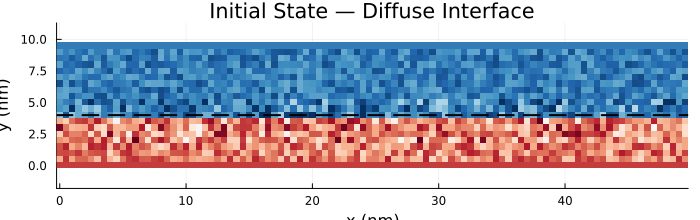

In [29]:
xs = (0:Nx-1) .* dx
ys = (0:Ny-1) .* dy

p_init = heatmap(xs, ys, c0_for_plot',
    c=cgrad(:RdBu, rev=true), clim=(0.0, 1.0),
    xlabel="x (nm)", ylabel="y (nm)",
    title="Initial State — Diffuse Interface",
    aspect_ratio=:equal, size=(700, 220), yflip=false, legend=false)
hline!(p_init, [interface_row*dy], lw=2, ls=:dash, lc=:black, label="Interface")
display(p_init)

## 9. Main Simulation Loop

Each iteration:
1. Records snapshots and energy at prescribed iterations
2. Advances `c` with one Cahn-Hilliard explicit Euler step
3. Re-solves the Laplace equation for the updated conductivity field (more iterations as channels sharpen)
4. Captures an animation frame every `anim_every` steps

In [31]:
c     = copy(c0)
c_new = copy(c0)
V     = zeros(Nx, Ny)

# Linear potential initialisation
for j in 1:Ny
    V[:, j] .= V_bot + (V_top - V_bot) * (j-1)/(Ny-1)
end

# Warm-up Laplace solve
solve_laplace!(V, c; n_iter=100)

# ── Logging / snapshot storage ────────────────────────────────────────────────
energy_log  = Float64[]
iter_log    = Int[]
snap_c      = Dict{Int, Matrix{Float64}}()
snap_V      = Dict{Int, Matrix{Float64}}()
snap_iters  = [0, N_pre, N_total]
anim        = Animation()
mass0       = sum(c)

println("\nStarting simulation...")
t0 = time()

for iter in 0:N_total

    # ── Snapshots ──────────────────────────────────────────────────────────────
    if iter in snap_iters
        snap_c[iter] = copy(c)
        snap_V[iter] = copy(V)
        F = free_energy(c, V)
        println(@sprintf("  iter=%6d   F = %.6f eV   mass = %.4f   max_c = %.3f",
                         iter, F, sum(c), maximum(c)))
    end

    # ── Progress report ────────────────────────────────────────────────────────
    if iter % 5000 == 0 && iter > 0
        println(@sprintf("  Progress: %d/%d  (%.0f%%)", iter, N_total, 100*iter/N_total))
    end

    # ── Energy logging ─────────────────────────────────────────────────────────
    if iter < 1000 && iter % 10 == 0 || iter >= 1000 && iter % 200 == 0
        push!(energy_log, free_energy(c, V))
        push!(iter_log,   iter)
    end

    # ── Animation frame ────────────────────────────────────────────────────────
    if iter % anim_every == 0
        p = heatmap(xs, ys, c',
            c=cgrad(:RdBu, rev=true), clim=(0.0, 1.0),
            xlabel="x (nm)", ylabel="y (nm)",
            title=@sprintf("Channel Growth — iter=%d", iter),
            aspect_ratio=:equal, size=(700, 220),
            yflip=false, legend=false)
        frame(anim, p)
    end

    iter == N_total && break

    # ── Cahn-Hilliard update ───────────────────────────────────────────────────
    ch_step!(c, V, c_new)
    copyto!(c, c_new)

    # ── Laplace solve (more iters as channels sharpen) ─────────────────────────
    n_rb = iter < 3000 ? RB_ITERS : 2*RB_ITERS
    solve_laplace!(V, c; n_iter=n_rb)
end

elapsed = time() - t0
println(@sprintf("\nDone! %.1f s  |  %.2f ms/iter", elapsed, 1000*elapsed/N_total))
println(@sprintf("Mass conservation: initial=%.4f  final=%.4f  drift=%.6f",
                 mass0, sum(c), abs(sum(c)-mass0)))


Starting simulation...
  iter=     0   F = -100.024739 eV   mass = 831.0981   max_c = 1.000
  iter=   300   F = -91.353529 eV   mass = 830.4377   max_c = 0.966
  Progress: 5000/30000  (17%)
  Progress: 10000/30000  (33%)
  Progress: 15000/30000  (50%)
  Progress: 20000/30000  (67%)
  Progress: 25000/30000  (83%)
  iter= 30000   F = -126.046390 eV   mass = 856.3444   max_c = 0.850
  Progress: 30000/30000  (100%)

Done! 273.8 s  |  9.13 ms/iter
Mass conservation: initial=831.0981  final=856.3444  drift=25.246290


## 10. Save Animation

In [33]:
gif_path = joinpath(@__DIR__, "filament_growth_vertical.gif")
gif(anim, gif_path, fps=15)
println("Animation saved → $gif_path")

Animation saved → C:\Users\Thanu T\Downloads\filament_growth_vertical.gif


[ Info: Saved animation to C:\Users\Thanu T\Downloads\filament_growth_vertical.gif


## 11. Snapshot Panels (c, d, e, f)

Four-panel figure showing the order parameter `c` at:
- **(c)** Initial state
- **(d)** Pre-formed state (`iter = N_pre`)
- **(e)** Same as initial (reference)
- **(f)** Final formed state (`iter = N_total`)

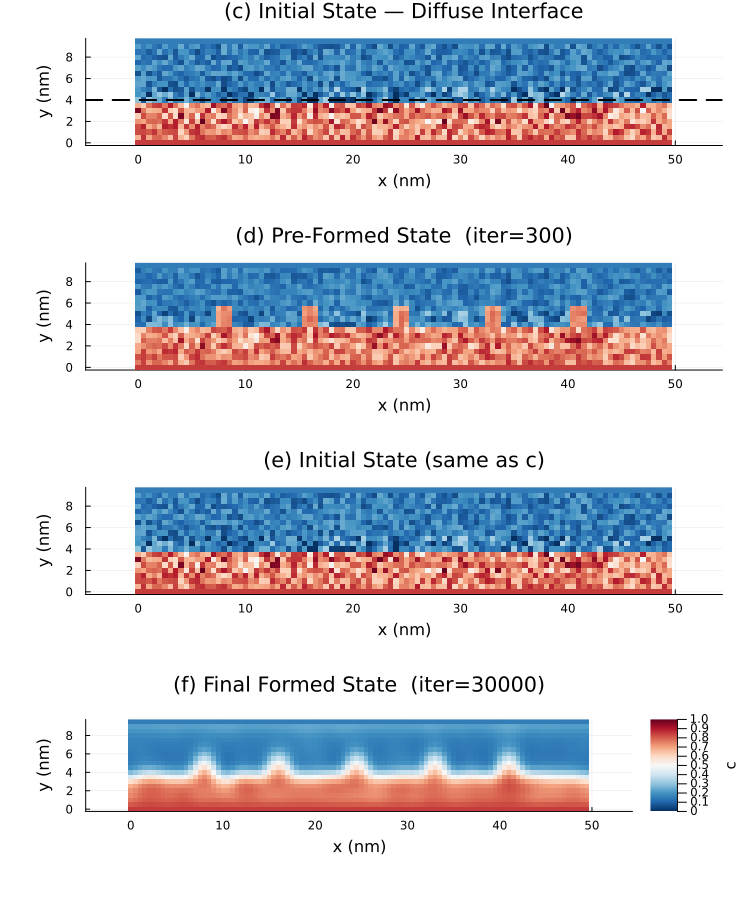

Saved → fig4_panels_cdef_vertical.png


In [35]:
titles = Dict(
    0       => "(c) Initial State — Diffuse Interface",
    N_pre   => "(d) Pre-Formed State  (iter=$N_pre)",
    N_total => "(f) Final Formed State  (iter=$N_total)"
)
plots_snap = []
for it in [0, N_pre, N_total]
    haskey(snap_c, it) || continue
    ci = (it == 0) ? c0_for_plot : snap_c[it]   # ← CHANGED
    p = heatmap(xs, ys, ci',
        c=cgrad(:RdBu, rev=true), clim=(0.0, 1.0),
        xlabel="x (nm)", ylabel="y (nm)",
        title=titles[it],
        colorbar_title = it == N_total ? "c" : "",
        colorbar       = it == N_total,
        aspect_ratio=:equal, size=(700, 220),
        yflip=false, legend=false)
    it == 0 && hline!(p, [interface_row*dy], lw=2, ls=:dash, lc=:black)
    push!(plots_snap, p)
end
# Panel (e) — duplicate of initial state
p_e = heatmap(xs, ys, c0_for_plot',             # ← CHANGED
    c=cgrad(:RdBu, rev=true), clim=(0.0, 1.0),
    xlabel="x (nm)", ylabel="y (nm)",
    title="(e) Initial State (same as c)",
    colorbar=false, aspect_ratio=:equal,
    size=(700, 220), yflip=false, legend=false)
plots_ordered = [plots_snap[1], plots_snap[2], p_e, plots_snap[3]]
fig_snap = plot(plots_ordered...,
    layout=(4,1), size=(750, 900),
    left_margin=10Plots.mm, bottom_margin=6Plots.mm)
display(fig_snap)
savefig(fig_snap, joinpath(@__DIR__, "fig4_panels_cdef_vertical.png"))
println("Saved → fig4_panels_cdef_vertical.png")

## 12. Free Energy Convergence Plot

Tracks the total free energy `F` over all iterations to confirm the system is relaxing toward equilibrium.

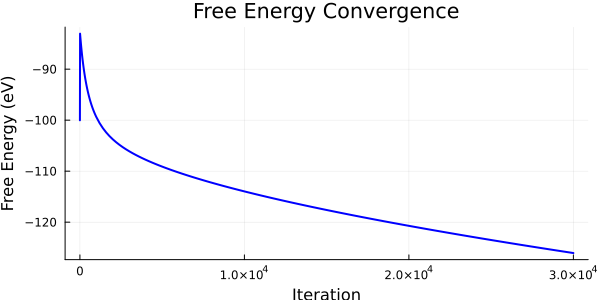

Energy plot saved ✓


In [37]:
p_energy = plot(iter_log, energy_log,
    xlabel="Iteration", ylabel="Free Energy (eV)",
    title="Free Energy Convergence",
    lw=2, lc=:blue, legend=false,
    size=(600, 300))

display(p_energy)
savefig(p_energy, joinpath(@__DIR__, "energy_convergence.png"))
println("Energy plot saved ✓")